In [ ]:
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import math



def save_graph(G, n, a):
	# nx.write_graphml(G, f"./graphs/G_n={n}_a={a}.graphml")
	nx.write_graph6(G, f"./graphs/G_n={n}_a={a}.g6")

def save_graphs(graph_list):
	for G, n, a in graph_list:
		save_graph(G, n, a)

def display_graphs(graphs, figsize=(15, 15)):
	def axes_division(x):
		factor1 = 1
		for i in range(1, int(math.sqrt(x))+1):
			if x % i == 0:
				factor1 = i
		return int(factor1), int(x/factor1)
	
	rows, cols = axes_division(len(graphs))
	fig, axes = plt.subplots(rows, cols, figsize=figsize)
	# fix: flatten the plot axes
	axes = np.array(axes).flatten()
	
	for i, (graph_touple, ax) in enumerate(zip(graphs, axes)):
		G, n, a = graph_touple
		
		pos = nx.spring_layout(G, seed=100)
		# pos = nx.spring_layout(G, k=0.8, iterations=200)  
		nx.draw(G, pos, ax=ax, with_labels=True, node_size=20, font_size=10, node_color=['red' if G.nodes[n].get("infected") else 'lightgray' for n in G])
		ax.set_title(f"Graph C({n}, {a})")
		ax.set_aspect('equal')

	plt.tight_layout()
	plt.show()

def generate_graphs(n):
	n_half = int(n/2)
	graphs = []
	
	def add_candidate_graph(H, a):
		nonlocal graphs
		for (G_i, _, _) in graphs:
			if nx.is_isomorphic(G_i, H):
				return
		graphs.append((H, n, a))
	
	for a in range(n_half):
		gcd = np.gcd(a, n_half)
		condition = (1 <= a < n_half and gcd == 1)
		
		if condition:
			g = nx.circulant_graph(n, [a, -a, n_half])
			add_candidate_graph(g, a)
			# print(f"a={a} n={n}")
	
	print(f"number of graphs for n={n} :", len(graphs))
	return graphs


number of graphs for n=8 : 1
[[0 1 0 0 1 0 0 1]
 [1 0 1 0 0 1 0 0]
 [0 1 0 1 0 0 1 0]
 [0 0 1 0 1 0 0 1]
 [1 0 0 1 0 1 0 0]
 [0 1 0 0 1 0 1 0]
 [0 0 1 0 0 1 0 1]
 [1 0 0 1 0 0 1 0]]
[[7, 1, 4], [0, 2, 5], [1, 3, 6], [2, 4, 7], [0, 3, 5], [1, 4, 6], [2, 5, 7], [0, 3, 6]]
infected node:  4
infected node:  7
infected node:  5
infected node:  6


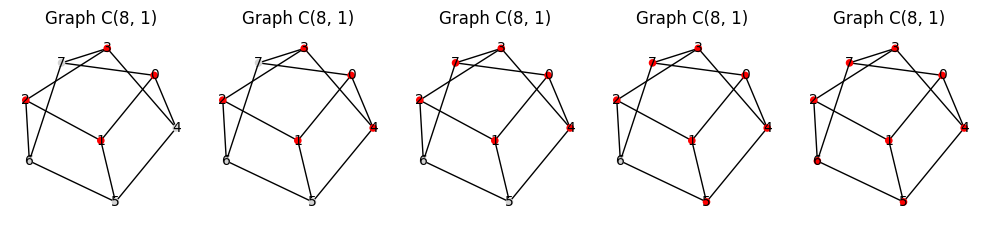

In [3]:
def is_infectable(node):
    node_N = list(nx.all_neighbors(G, node))
    if len(node_N) < 2:
        return False
    infected_N_counter = 0
    for i_neighbor in node_N:
        if G.nodes[i_neighbor].get("infected"):
            infected_N_counter += 1
    return (infected_N_counter >= 2)

def fully_endemic(G):
    infected_nodes = [n for n in G.nodes if G.nodes[n].get("infected")]
    healthy_nodes = [n for n in G.nodes if not G.nodes[n].get("infected")]

    itter_number = 0
    while len(healthy_nodes) > 0:
        for node in healthy_nodes:
            if is_infectable(node):
                G.nodes[node]["infected"] = True
                infected_nodes.append(node)
                healthy_nodes.remove(node)

        itter_number+=1
        print("itter number=", itter_number, "infected_nodes:", infected_nodes, "healthy_nodes", healthy_nodes)
        if itter_number > n:
            break



def infection_spread(G, n, a):
    graph_stages = [G.copy()]
    infected_nodes = [n for n in G.nodes if G.nodes[n].get("infected")]
    healthy_nodes = [n for n in G.nodes if not G.nodes[n].get("infected")]

    itter_number = 0
    while len(healthy_nodes) > 0:
        for node in healthy_nodes:
            if is_infectable(node):
                G.nodes[node]["infected"] = True
                graph_stages.append(G.copy())
                print("infected node: ", node)
                infected_nodes.append(node)
                healthy_nodes.remove(node)

        itter_number+=1
        # print("itter number=", itter_number, "infected_nodes:", infected_nodes, "healthy_nodes", healthy_nodes)
        if itter_number > n:
            break

    return [(H, n, a) for H in graph_stages]

G, n, a = generate_graphs(8)[0]

A = nx.adjacency_matrix(G)

print(A.toarray())

# fully_endemic(G)

def adjacency_list(G):
    ajd_list = []
    for i in G.nodes:
        ajd_list.append(list(nx.all_neighbors(G, i)))
    return ajd_list

print(adjacency_list(G))

G.nodes[0]["infected"] = 1
G.nodes[1]["infected"] = 1
G.nodes[2]["infected"] = 1
G.nodes[3]["infected"] = 1

infection_stages = infection_spread(G, n, a)
display_graphs(infection_stages, figsize=(10, 10))


In [61]:
def show_graph_infection(H):
    print("C=", end="")
    for j in H.nodes:
        if H.nodes[j].get("infected"):
            print(1, end="")
        else:
            print(0, end="")
    print()





def infection_graph_permuation(vertex_list, infection_number, z=0):
    if infection_number == 0:
        yield vertex_list
    
    # rekurzivni klic
    for i, e in enumerate(vertex_list):
        if i < z:       # if over the duplication index
            continue
        if e:           # if it is already infected
            continue
        else:
            vertex_list_i = vertex_list[:]  # make a copy of an array
            vertex_list_i[i] = 1
            yield from infect_graph(vertex_list_i, infection_number-1, i)


def infect_graph(H, infection_number, z=0):
    # ustavitveni pogoj
    if infection_number == 0:
        show_graph_infection(H)
        # run the infect function
        return
    
    # rekurzivni klic
    for i in H.nodes:
        if i < z or H.nodes[i].get("infected"):           # if it is already infected
            continue
        else:
            G_i = G.copy()
            G_i.nodes[i]["infected"] = 1
            # print(G_i.nodes[i])
            infect_graph(G_i, infection_number-1, i)
            break

    



graphs = generate_graphs(8)
G, n, a = graphs[0]

infect_graph(G, 4)


number of graphs for n=8 : 1


KeyboardInterrupt: 

number of graphs for n=4 : 1
number of graphs for n=6 : 2
number of graphs for n=8 : 1
number of graphs for n=10 : 2
number of graphs for n=12 : 1
number of graphs for n=14 : 2
number of graphs for n=16 : 1
number of graphs for n=18 : 2
number of graphs for n=20 : 1
number of graphs for n=22 : 2
number of graphs for n=24 : 1
number of graphs for n=26 : 2
number of graphs for n=28 : 1
number of graphs for n=30 : 2
number of graphs for n=32 : 1
number of graphs for n=34 : 2
number of graphs for n=36 : 1
25


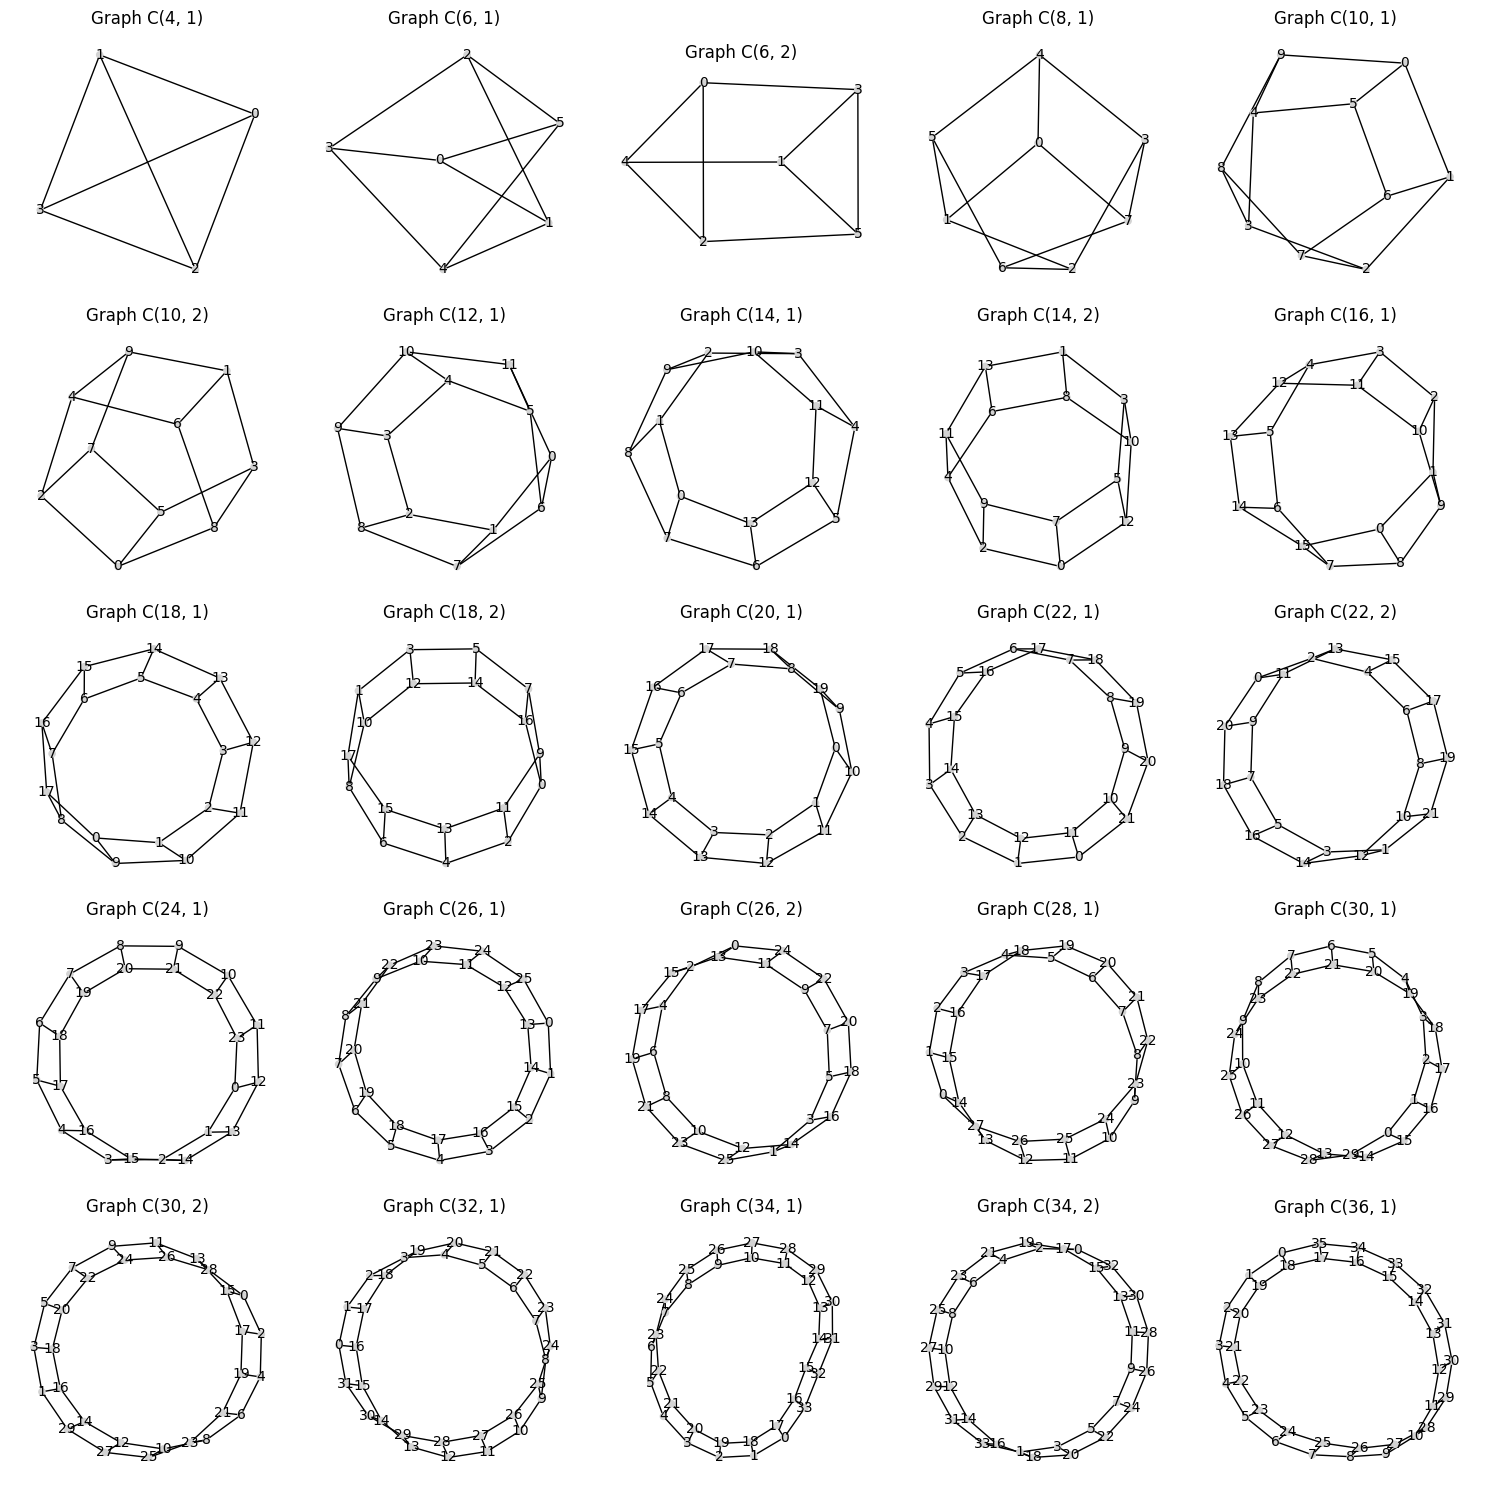

In [15]:
search_space = 36
graphs = []

for i in range(4, search_space+1, 2):
    n_graph_list = generate_graphs(i)
    graphs += n_graph_list

print(len(graphs))

display_graphs(graphs)
save_graphs(graphs)


In [13]:
import random

G, n, a = generate_graphs(22)[1]
# fully_endemic(G)

G.nodes[0]["infected"] = 1

print(G.nodes)

def build_tree(G, start_vertex=0):
    tree_graph = nx.Graph()
    tree_graph.add_nodes_from(G.nodes)
    current_vertex = start_vertex

    visited_vertexes = set()
    vertexes_2_visit = set([start_vertex])
        
    while True:
        current_vertex = vertexes_2_visit.pop()
        visited_vertexes.add(current_vertex)

        neighbor_list = list(nx.all_neighbors(G, current_vertex))
        random2neighbors = set(random.sample(i_neighbors_list, k=min(len(i_neighbors_list), 2)))

        vertexes_2_visit |= random2neighbors

        print("visited_vertexes:", visited_vertexes, " vertexes_2_visit:", vertexes_2_visit)

        # iterate over a snapshot
        for vertex_i in list(vertexes_2_visit):
            G.add_edge(current_vertex, vertex_i)
            visited_vertexes.add(vertex_i)

            i_neighbors = visited_vertexes - set(nx.all_neighbors(G, current_vertex))

            # sample from a list, not a set
            i_neighbors_list = list(i_neighbors)
            random2neighbors = set(random.sample(i_neighbors_list, k=min(len(i_neighbors_list), 2)))

            vertexes_2_visit |= random2neighbors

            current_vertex = vertexes_2_visit.pop()
            print(current_vertex)
            if len(visited_vertexes) >= len(G.nodes):
                break

build_tree(G)


number of graphs for n=22 : 2
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21]


UnboundLocalError: local variable 'i_neighbors_list' referenced before assignment

In [16]:
import random

s = {1, 2, 3, 4}

t = {1}

neighbors = [1, 2, 3]

t | set(random.sample(neighbors, k=min(len(neighbors), 2)))


visited_vertexes = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21}
vertexes_2_visit = {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21}

vertexes_2_visit.diffrence(visited_vertexes)


AttributeError: 'set' object has no attribute 'diffrence'

In [223]:
stack = set()

stack.add(0)
stack.add(1)
stack.add(2)
stack.add(3)

print(stack.pop())

0


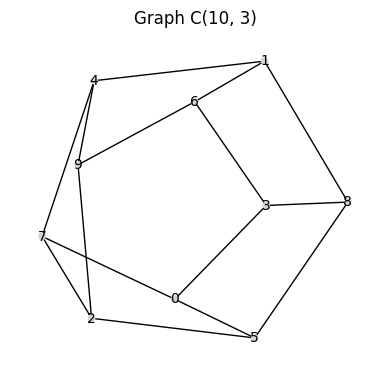

number of graphs for n=10 : 4


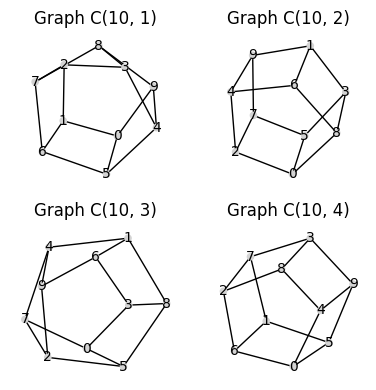

True

In [89]:
G = nx.circulant_graph(10, [3, -3, 5])



display_graphs([(G, 10, 3)], figsize=(4, 4))


# graphs = generate_graphs(8)
# G, n, a = graphs[0]



def generate_graphs2(n):
	n_half = int(n/2)
	graphs = []
	
	def add_candidate_graph(H, a):
		nonlocal graphs
		for (G_i, n_i, a_i) in graphs:
			if nx.is_isomorphic(G_i, H):
				print(f"n={n_i} a={a_i} is isomorpic")
				return
		graphs.append((H, n, a))
	
	for a in range(n_half):
		gcd = np.gcd(a, n_half)
		condition = (1 <= a < n_half and gcd == 1)
		
		if condition:
			g = nx.circulant_graph(n, [a, -a, n_half])
			add_candidate_graph(g, a)
	
	print(f"number of graphs for n={n} :", len(graphs))
	return graphs


graphs = generate_graphs2(10)
display_graphs(graphs, figsize=(4, 4))



nx.is_isomorphic(graphs[0][0], graphs[2][0])
